In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv("C:/CSVFiles/House Price Prediction Data.csv")
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [3]:
df.shape

(999, 23)

### EDA

In [4]:
df.isnull() .sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [5]:
df.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

In [6]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,500.000000,2.914915,2739.569570,257.066687,0.131752,2006.709710,14.766767,15.428428,18.290290,5.462462,5.391391
std,288.530761,1.426828,1306.529168,141.533299,0.130940,9.921931,8.995137,8.738613,9.921931,2.877308,2.889752
min,1.000000,1.000000,502.000000,11.590000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,250.500000,2.000000,1617.500000,134.655000,0.050000,1998.000000,7.000000,8.000000,9.500000,3.000000,3.000000
50%,500.000000,3.000000,2639.000000,261.840000,0.100000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,749.500000,4.000000,3886.500000,381.735000,0.160000,2015.500000,23.000000,23.000000,27.000000,8.000000,8.000000
max,999.000000,5.000000,5000.000000,499.570000,0.970000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


### Pre Processing

In [7]:
df.drop('ID' , axis= 1 , inplace= True)

In [8]:
df.drop('Locality', axis=1 , inplace= True)

#### Using Ordinal Encoder to Encode Ordinal Values

In [9]:
ordinal_columns = ['Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Facing', 'Security']

categories = [['Apartment', 'Independent House', 'Villa'],
              ['Unfurnished', 'Semi-furnished', 'Furnished'],
              ['Low', 'Medium', 'High'],
              ['South', 'East', 'West', 'North'],  
              ['No', 'Yes']]

encoder = OrdinalEncoder(categories=categories)
df[ordinal_columns] = encoder.fit_transform(df[ordinal_columns])

#### Seperating Categorical and Numerical Columns

In [10]:
categorical_col = [column for column in df.columns if df[column].dtype == 'object']
numerical_col = [column for column in df.columns if df[column].dtype != 'object']

In [11]:
len(categorical_col), len(numerical_col)

(6, 15)

#### Lower Cap Strings for Better Accessibility

In [12]:
for column in categorical_col:
    df[column] = df[column].str.lower()

#### Checking Correlation

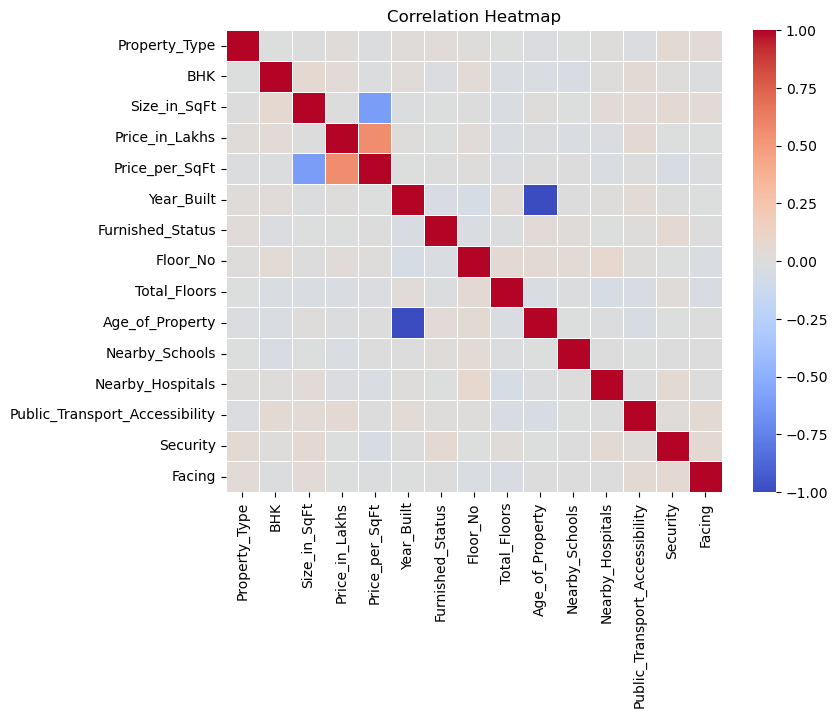

In [13]:
correlation_matrix = df[numerical_col].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### Splitting Dataset and Picking out Smaller Sample

In [14]:
# Randomly sample 40% of the data
df_sampled = df.sample(frac=0.4, random_state=1)

In [15]:
df_sampled

,State,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
507,rajasthan,jaipur,1.0,1,2736,445.96,0.16,2019,1.0,0,...,6,9,7,2.0,no,0.0,"clubhouse, pool, playground",1.0,broker,under_construction
608,haryana,gurgaon,1.0,5,3438,17.27,0.01,2019,0.0,12,...,6,6,2,2.0,yes,0.0,"gym, playground, pool",3.0,broker,ready_to_move
452,jharkhand,ranchi,2.0,2,2583,496.99,0.19,2023,0.0,8,...,2,3,10,2.0,no,1.0,"pool, garden, gym, playground, clubhouse",2.0,owner,ready_to_move
368,haryana,gurgaon,0.0,3,515,110.93,0.22,2008,0.0,29,...,17,4,9,2.0,no,0.0,"playground, pool",3.0,owner,ready_to_move
242,punjab,amritsar,1.0,3,3925,229.96,0.06,1991,1.0,22,...,34,3,10,0.0,no,1.0,"garden, gym, playground",1.0,owner,ready_to_move
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,odisha,bhubaneswar,2.0,1,1677,15.96,0.01,2009,2.0,21,...,16,8,7,0.0,no,1.0,"clubhouse, pool",1.0,owner,under_construction
554,punjab,ludhiana,2.0,4,2881,442.42,0.15,2003,1.0,6,...,22,3,3,0.0,yes,1.0,"clubhouse, garden, gym, pool, playground",2.0,broker,ready_to_move
103,punjab,ludhiana,2.0,4,4925,338.20,0.07,2004,2.0,4,...,21,8,6,0.0,no,1.0,"playground, garden, gym, pool",1.0,owner,under_construction
965,gujarat,ahmedabad,0.0,4,756,29.75,0.04,2012,0.0,15,...,13,6,2,0.0,yes,0.0,"garden, playground, pool, clubhouse, gym",0.0,owner,under_construction


In [16]:
X = df_sampled.drop('Price_in_Lakhs', axis=1)  
y = df_sampled['Price_in_Lakhs']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [17]:
len(X_test), len(X_train)

(80, 320)

#### Encoding Categorical Variables

In [18]:
train_dicts = X_train.to_dict(orient='records') # using resampled data as our train feature
test_dicts = X_test.to_dict(orient='records')

In [19]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

#### Training the Model

In [20]:
model_results = []

def evaluate_model(y, y_pred):
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    return mae, mse, rmse, r2

In [21]:
model_results

[]

#### Linear Regression

In [22]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [23]:
y_pred = model.predict(X_test)
mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)
mae, mse, rmse, r2

(110.75840238485557,
 20085.554849151646,
 np.float64(141.7235155122524),
 0.05186840229624412)

In [24]:
model_results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

In [25]:
model_results

[{'Model': 'Linear Regression',
  'MAE': 110.75840238485557,
  'MSE': 20085.554849151646,
  'RMSE': np.float64(141.7235155122524),
  'R2': 0.05186840229624412}]